# SQ1-4 — Guess-rate proxy for prior-dominated ("hallucination-like") trials

**Motivating question:** Without fitting the full switching/hierarchical Bayesian model, can we detect a "guessed from the prior" mode using a cheap trial-level heuristic, and does its rate scale with sensory reliability and prior strength the way prior-overweighting accounts (predictive coding / computational psychiatry) predict?

- **SQ1** — Visual check: does the error distribution look bimodal in specific coherence x `prior_std` cells?
- **SQ2** — Cheap proxy: per trial, is the estimate closer to the true stimulus ("looked") or to the prior mean ("guessed")?
- **SQ3** — Does guess-rate increase as `motion_coherence` decreases?
- **SQ4** — Does guess-rate increase as `prior_std` decreases (stronger prior)?

Dataset: Laquitaine & Gardner (2017/2018) `data01_direction4priors.csv`, same source as the other notebooks in this folder.

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["figure.figsize"] = [10, 4]
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG = np.random.default_rng(42)

## 1. Load data and compute circular error

Same loading/cleaning code as `q1_estimate_error_timecourse.ipynb` and `hierarchical_bayesian_observer.ipynb`.

In [2]:
DATA_URL = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data01_direction4priors.csv")

if not os.path.exists(DATA_PATH):
    r = requests.get(DATA_URL, timeout=30)
    r.raise_for_status()
    with open(DATA_PATH, "wb") as f:
        f.write(r.content)

data = pd.read_csv(DATA_PATH)


def wrap_deg(x):
    """wrap angle in degrees to [0, 360)"""
    return np.mod(x, 360)


def circ_diff_deg(a, b):
    """shortest signed circular difference a - b, in degrees, range (-180, 180]"""
    return np.mod(np.asarray(a) - np.asarray(b) + 180, 360) - 180


data["estimate_angle"] = wrap_deg(np.degrees(np.arctan2(data["estimate_y"], data["estimate_x"])))
data["error_deg"] = circ_diff_deg(data["estimate_angle"], data["motion_direction"])

# drop trials with no valid estimate
data = data.dropna(subset=["estimate_angle", "motion_direction", "prior_std", "prior_mean", "motion_coherence"]).reset_index(drop=True)

print(f"N trials: {len(data)}, N subjects: {data['subject_id'].nunique()}")
data[["subject_id", "motion_direction", "motion_coherence", "prior_std", "prior_mean", "estimate_angle", "error_deg"]].head()

N trials: 83210, N subjects: 12


,subject_id,motion_direction,motion_coherence,prior_std,prior_mean,estimate_angle,error_deg
0,1,225,0.12,10,225,225.583113,0.583113
1,1,225,0.12,10,225,223.291282,-1.708718
2,1,235,0.06,10,225,231.312691,-3.687309
3,1,225,0.06,10,225,230.166776,5.166776
4,1,215,0.24,10,225,229.020860,14.020860


## 2. SQ1 — Visual check across all conditions

**Hypothesis:** bimodality (if present) is concentrated in specific coherence x `prior_std` cells, likely low coherence + low `prior_std` (strong, informative prior).

Plot the full grid (all 4 `prior_std` x 3 `motion_coherence` = 12 cells), pooled across subjects, instead of only the top-3 highest-BC cells shown in `hierarchical_bayesian_observer.ipynb`.

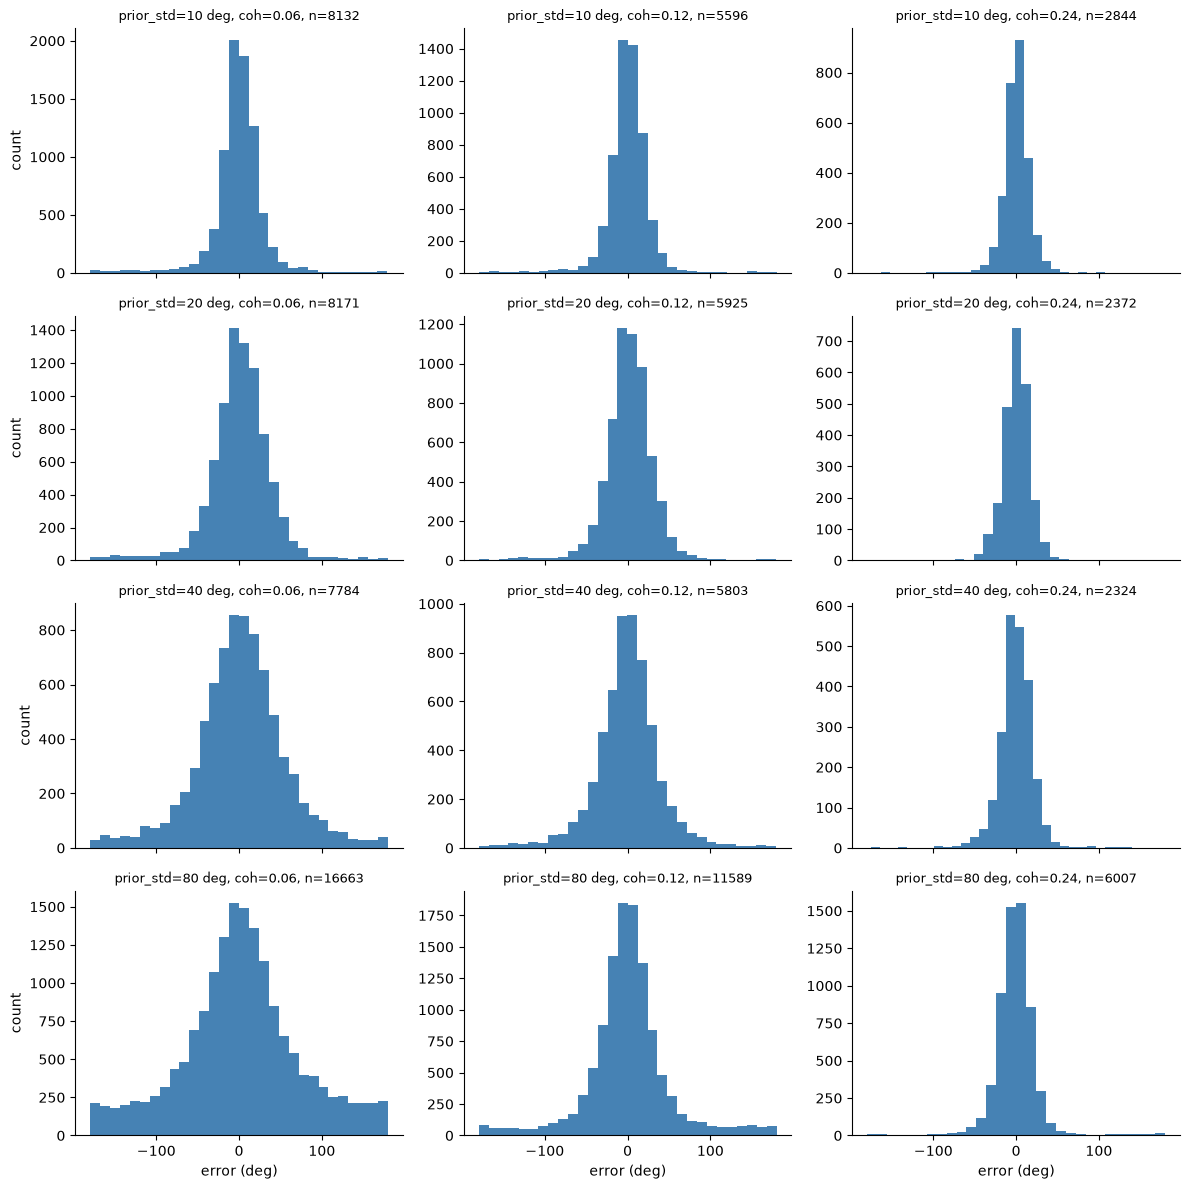

In [3]:
prior_stds = sorted(data["prior_std"].unique())
coherences = sorted(data["motion_coherence"].unique())

fig, axes = plt.subplots(len(prior_stds), len(coherences), figsize=(4 * len(coherences), 3 * len(prior_stds)), sharex=True)

for i, ps in enumerate(prior_stds):
    for j, coh in enumerate(coherences):
        ax = axes[i, j]
        subset = data[(data.prior_std == ps) & (data.motion_coherence == coh)]
        ax.hist(subset["error_deg"], bins=30, color="steelblue")
        ax.set_title(f"prior_std={ps} deg, coh={coh}, n={len(subset)}", fontsize=9)
        if i == len(prior_stds) - 1:
            ax.set_xlabel("error (deg)")
        if j == 0:
            ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## 3. SQ2 — Cheap "guessed vs. looked" proxy

**Hypothesis:** a meaningful subset of trials are closer to the prior mean than to the true stimulus, and this subset is non-trivial specifically in weak-evidence / strong-prior conditions.

Per trial: `dist_to_stim = |error_deg|` (circular distance estimate-to-stimulus), `dist_to_prior` = circular distance estimate-to-`prior_mean`. Label `guessed = dist_to_prior < dist_to_stim`.

**Ambiguous-trial caveat:** when `motion_direction == prior_mean` (stimulus already sits at the prior), `dist_to_stim` and `dist_to_prior` are identical — the trial carries no information about looked-vs-guessed and must be excluded, not counted either way.

In [4]:
data["dist_to_stim"] = np.abs(data["error_deg"])
data["dist_to_prior"] = np.abs(circ_diff_deg(data["estimate_angle"], data["prior_mean"]))
data["stim_prior_offset"] = np.abs(circ_diff_deg(data["motion_direction"], data["prior_mean"]))

# exclude ambiguous trials where stimulus sits at (or essentially at) the prior mean
AMBIGUOUS_TOL_DEG = 1.0
ambiguous = data["stim_prior_offset"] < AMBIGUOUS_TOL_DEG
print(f"Excluding {ambiguous.sum()} ambiguous trials (stimulus ~= prior mean) out of {len(data)}")

data_sq = data[~ambiguous].copy()
data_sq["guessed"] = (data_sq["dist_to_prior"] < data_sq["dist_to_stim"]).astype(int)

print(f"Overall guess-rate: {data_sq['guessed'].mean():.3f}")
data_sq[["subject_id", "motion_coherence", "prior_std", "dist_to_stim", "dist_to_prior", "guessed"]].head()

Excluding 13552 ambiguous trials (stimulus ~= prior mean) out of 83210
Overall guess-rate: 0.439


,subject_id,motion_coherence,prior_std,dist_to_stim,dist_to_prior,guessed
2,1,0.06,10,3.687309,6.312691,0
4,1,0.24,10,14.020860,4.020860,1
5,1,0.24,10,18.291282,1.708718,1
6,1,0.06,10,8.270971,1.729029,1
7,1,0.12,10,4.853535,5.146465,0


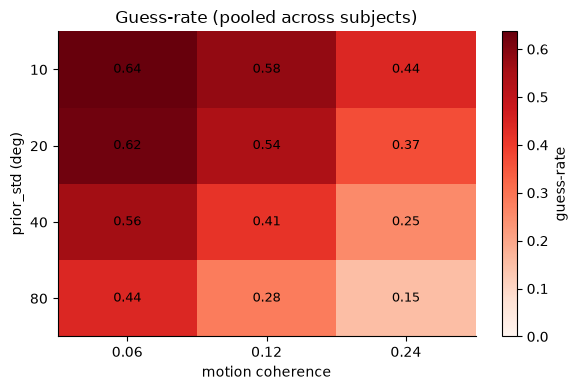

motion_coherence,0.06,0.12,0.24
prior_std,,,
10,0.637130,0.578349,0.441589
20,0.622850,0.539241,0.366559
40,0.559197,0.414203,0.254067
80,0.440913,0.283122,0.153968


In [5]:
guess_by_condition = (
    data_sq.groupby(["subject_id", "prior_std", "motion_coherence"])["guessed"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "guess_rate"})
)

pooled_guess_rate = (
    data_sq.groupby(["prior_std", "motion_coherence"])["guessed"]
    .mean()
    .reset_index()
    .pivot(index="prior_std", columns="motion_coherence", values="guessed")
)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pooled_guess_rate.values, cmap="Reds", aspect="auto", vmin=0, vmax=pooled_guess_rate.values.max())
ax.set_xticks(range(len(pooled_guess_rate.columns)))
ax.set_xticklabels(pooled_guess_rate.columns)
ax.set_yticks(range(len(pooled_guess_rate.index)))
ax.set_yticklabels(pooled_guess_rate.index)
ax.set_xlabel("motion coherence")
ax.set_ylabel("prior_std (deg)")
ax.set_title("Guess-rate (pooled across subjects)")
for i in range(pooled_guess_rate.shape[0]):
    for j in range(pooled_guess_rate.shape[1]):
        ax.text(j, i, f"{pooled_guess_rate.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="guess-rate")
plt.tight_layout()
plt.show()

pooled_guess_rate

## 4. SQ3 — Does guess-rate increase as `motion_coherence` decreases?

**Hypothesis:** guess-rate increases monotonically as `motion_coherence` decreases (weaker sensory evidence -> more reliance on the prior).

Regression uses per-(subject x condition) guess-rate as the unit of observation (144 rows), not individual trials, to avoid pseudo-replication inflating significance.

guess_rate ~ motion_coherence: slope=-1.386 (SE=0.159), r=-0.591, p=0.0000


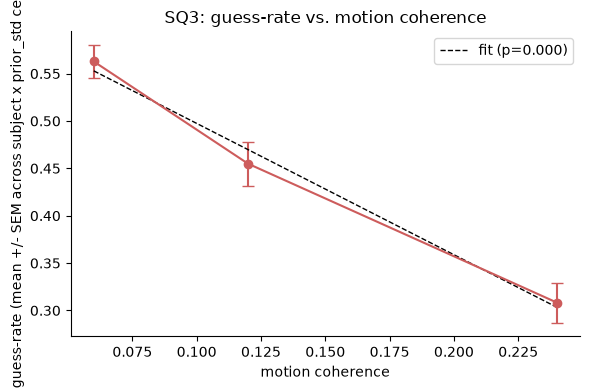

In [6]:
slope_coh, intercept_coh, r_coh, p_coh, se_coh = linregress(guess_by_condition["motion_coherence"], guess_by_condition["guess_rate"])
print(f"guess_rate ~ motion_coherence: slope={slope_coh:.3f} (SE={se_coh:.3f}), r={r_coh:.3f}, p={p_coh:.4f}")

coh_summary = guess_by_condition.groupby("motion_coherence")["guess_rate"].agg(["mean", "sem"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(coh_summary.index, coh_summary["mean"], yerr=coh_summary["sem"], fmt="o-", color="indianred", capsize=4)
x_line = np.array([guess_by_condition["motion_coherence"].min(), guess_by_condition["motion_coherence"].max()])
ax.plot(x_line, intercept_coh + slope_coh * x_line, "k--", linewidth=1, label=f"fit (p={p_coh:.3f})")
ax.set_xlabel("motion coherence")
ax.set_ylabel("guess-rate (mean +/- SEM across subject x prior_std cells)")
ax.set_title("SQ3: guess-rate vs. motion coherence")
ax.legend()
plt.tight_layout()
plt.show()

## 5. SQ4 — Does guess-rate increase as `prior_std` decreases (stronger prior)?

**Hypothesis:** guess-rate increases as `prior_std` decreases (a more concentrated/informative prior is a more attractive "guess").

Also fit a joint regression (`guess_rate ~ motion_coherence + prior_std`) to check SQ3 and SQ4 are independent effects rather than a shared confound (both vary block-wise/trial-wise in this design).

guess_rate ~ prior_std: slope=-0.0037 (SE=0.0005), r=-0.559, p=0.0000


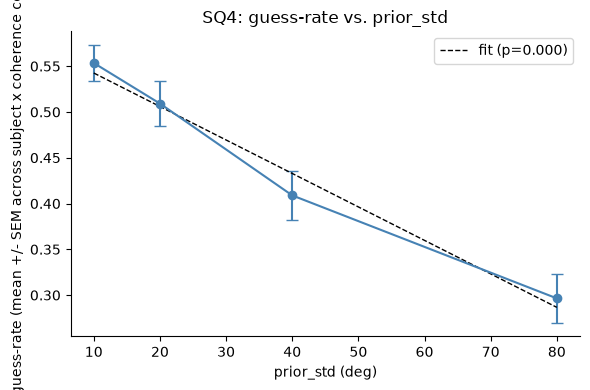

                            OLS Regression Results                            
Dep. Variable:             guess_rate   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     137.7
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           6.96e-34
Time:                        23:56:30   Log-Likelihood:                 124.23
No. Observations:                 144   AIC:                            -242.5
Df Residuals:                     141   BIC:                            -233.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7732      0.022  

In [7]:
import statsmodels.api as sm

slope_ps, intercept_ps, r_ps, p_ps, se_ps = linregress(guess_by_condition["prior_std"], guess_by_condition["guess_rate"])
print(f"guess_rate ~ prior_std: slope={slope_ps:.4f} (SE={se_ps:.4f}), r={r_ps:.3f}, p={p_ps:.4f}")

ps_summary = guess_by_condition.groupby("prior_std")["guess_rate"].agg(["mean", "sem"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(ps_summary.index, ps_summary["mean"], yerr=ps_summary["sem"], fmt="o-", color="steelblue", capsize=4)
x_line = np.array([guess_by_condition["prior_std"].min(), guess_by_condition["prior_std"].max()])
ax.plot(x_line, intercept_ps + slope_ps * x_line, "k--", linewidth=1, label=f"fit (p={p_ps:.3f})")
ax.set_xlabel("prior_std (deg)")
ax.set_ylabel("guess-rate (mean +/- SEM across subject x coherence cells)")
ax.set_title("SQ4: guess-rate vs. prior_std")
ax.legend()
plt.tight_layout()
plt.show()

# joint regression: guess_rate ~ motion_coherence + prior_std, to check the two effects are independent
X = sm.add_constant(guess_by_condition[["motion_coherence", "prior_std"]])
y = guess_by_condition["guess_rate"]
joint_model = sm.OLS(y, X).fit()
print(joint_model.summary())

## 6. Interpreting SQ1-4 (fill in after running)

- **SQ1:** Which cells in the histogram grid look two-humped by eye? Do they match the low-coherence / low-`prior_std` corner predicted by the hypothesis?
- **SQ2:** What is the overall guess-rate, and how much does it vary across the heatmap? A rate near 0 or near 1 everywhere would undermine the proxy's usefulness (no discriminating power).
- **SQ3:** Is `slope_coh` negative and `p_coh` significant? If the trend is flat or positive, that's a real negative result -- report it, then ask whether it rules out prior-overweighting here or reflects the coherence range tested being too narrow.
- **SQ4:** Is `slope_ps` negative (guess-rate rises as `prior_std` shrinks)? Check the joint OLS (`joint_model.summary()`) to confirm coherence and `prior_std` each contribute independently, not through a shared confound (they are both varied in this design, so check the correlation between them at the cell level too if the joint fit looks unstable).

**Before trusting any positive SQ3/4 result:** run SQ7 (baseline-observer negative control, see `hierarchical_bayesian_observer.ipynb` Section 3 for the no-switching simulator) to confirm the proxy doesn't mechanically produce a coherence/prior_std trend even when there is no true switching behavior.

## 7. SQ7 — Negative control: does a non-switching Bayesian observer show the same trend?

**Hypothesis (null):** a standard single-source Bayesian observer that always blends prior and evidence (no discrete switching) will *also* show `guess_rate` decreasing with `motion_coherence` and `prior_std`, simply because a stronger prior / noisier likelihood pulls its posterior mean further toward the prior mean. If so, SQ3/SQ4's positive result does **not** distinguish genuine switching/guessing from ordinary Bayesian blending.

We reproduce the baseline-observer simulation from `hierarchical_bayesian_observer.ipynb` (Section 3: von Mises product-of-priors posterior, always unimodal, no switching) and apply the exact same SQ2 guess-rate proxy to its simulated estimates.

In [8]:
def a1_inverse(R):
    """Approximate inverse of A1(kappa) = R (mean resultant length) for the von Mises
    MLE of concentration, from Fisher (1993), Statistical Analysis of Circular Data,
    equation p. 88 (same as `hierarchical_bayesian_observer.ipynb`)."""
    R = np.clip(np.asarray(R, dtype=float), 1e-8, 0.999999)
    return np.where(
        R < 0.53,
        2 * R + R ** 3 + 5 * R ** 5 / 6,
        np.where(
            R < 0.85,
            -0.4 + 1.39 * R + 0.43 / (1 - R),
            1 / (R ** 3 - 4 * R ** 2 + 3 * R),
        ),
    )


def kappa_from_errors(errors_deg):
    theta = np.radians(errors_deg)
    R = np.hypot(np.mean(np.cos(theta)), np.mean(np.sin(theta)))
    return float(a1_inverse(R))


def kappa_prior_from_std(prior_std_deg):
    std_rad = np.radians(prior_std_deg)
    return 1.0 / std_rad ** 2


def von_mises_combination(mu1, kappa1, mu2, kappa2):
    vx = kappa1 * np.cos(mu1) + kappa2 * np.cos(mu2)
    vy = kappa1 * np.sin(mu1) + kappa2 * np.sin(mu2)
    R = np.hypot(vx, vy)
    mu_R = np.arctan2(vy, vx)
    return mu_R, R


def simulate_baseline_trial(true_dir_deg, prior_mean_deg, kappa_sensory, kappa_prior, rng):
    true_dir = np.radians(true_dir_deg)
    prior_mean = np.radians(prior_mean_deg)
    m = rng.vonmises(true_dir, max(kappa_sensory, 1e-6))
    mu_R, R = von_mises_combination(m, kappa_sensory, prior_mean, kappa_prior)
    resp = rng.vonmises(mu_R, max(R, 1e-6))
    return np.degrees(resp) % 360


weakest_prior_std = data["prior_std"].max()
kappa_sensory_by_coh = {
    coh: kappa_from_errors(grp["error_deg"])
    for coh, grp in data[data.prior_std == weakest_prior_std].groupby("motion_coherence")
}

data["kappa_sensory"] = data["motion_coherence"].map(kappa_sensory_by_coh)
data["kappa_prior"] = kappa_prior_from_std(data["prior_std"])

data["baseline_estimate"] = [
    simulate_baseline_trial(row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, RNG)
    for row in data.itertuples()
]
data["baseline_error_deg"] = circ_diff_deg(data["baseline_estimate"], data["motion_direction"])
data[["motion_direction", "prior_mean", "kappa_sensory", "kappa_prior", "baseline_estimate", "baseline_error_deg"]].head()

,motion_direction,prior_mean,kappa_sensory,kappa_prior,baseline_estimate,baseline_error_deg
0,225,225,2.239938,32.828064,248.002956,23.002956
1,225,225,2.239938,32.828064,220.898352,-4.101648
2,235,225,1.095569,32.828064,223.340333,-11.659667
3,225,225,1.095569,32.828064,218.953731,-6.046269
4,215,225,6.007733,32.828064,238.758057,23.758057


In [9]:
data["baseline_dist_to_stim"] = np.abs(data["baseline_error_deg"])
data["baseline_dist_to_prior"] = np.abs(circ_diff_deg(data["baseline_estimate"], data["prior_mean"]))

data_sq_baseline = data[~ambiguous].copy()
data_sq_baseline["guessed_baseline"] = (
    data_sq_baseline["baseline_dist_to_prior"] < data_sq_baseline["baseline_dist_to_stim"]
).astype(int)

print(f"Overall guess-rate (real data): {data_sq['guessed'].mean():.3f}")
print(f"Overall guess-rate (baseline, non-switching observer): {data_sq_baseline['guessed_baseline'].mean():.3f}")

guess_by_condition_baseline = (
    data_sq_baseline.groupby(["subject_id", "prior_std", "motion_coherence"])["guessed_baseline"]
    .mean()
    .reset_index()
    .rename(columns={"guessed_baseline": "guess_rate_baseline"})
)

slope_coh_base, intercept_coh_base, r_coh_base, p_coh_base, se_coh_base = linregress(
    guess_by_condition_baseline["motion_coherence"], guess_by_condition_baseline["guess_rate_baseline"]
)
slope_ps_base, intercept_ps_base, r_ps_base, p_ps_base, se_ps_base = linregress(
    guess_by_condition_baseline["prior_std"], guess_by_condition_baseline["guess_rate_baseline"]
)

print(f"\n[baseline] guess_rate ~ motion_coherence: slope={slope_coh_base:.3f} (SE={se_coh_base:.3f}), r={r_coh_base:.3f}, p={p_coh_base:.4f}")
print(f"[baseline] guess_rate ~ prior_std: slope={slope_ps_base:.4f} (SE={se_ps_base:.4f}), r={r_ps_base:.3f}, p={p_ps_base:.4f}")
print(f"\n[real data, for comparison] slope_coh={slope_coh:.3f} (p={p_coh:.4f}), slope_ps={slope_ps:.4f} (p={p_ps:.4f})")

Overall guess-rate (real data): 0.439
Overall guess-rate (baseline, non-switching observer): 0.515

[baseline] guess_rate ~ motion_coherence: slope=-0.865 (SE=0.140), r=-0.459, p=0.0000
[baseline] guess_rate ~ prior_std: slope=-0.0043 (SE=0.0002), r=-0.826, p=0.0000

[real data, for comparison] slope_coh=-1.386 (p=0.0000), slope_ps=-0.0037 (p=0.0000)


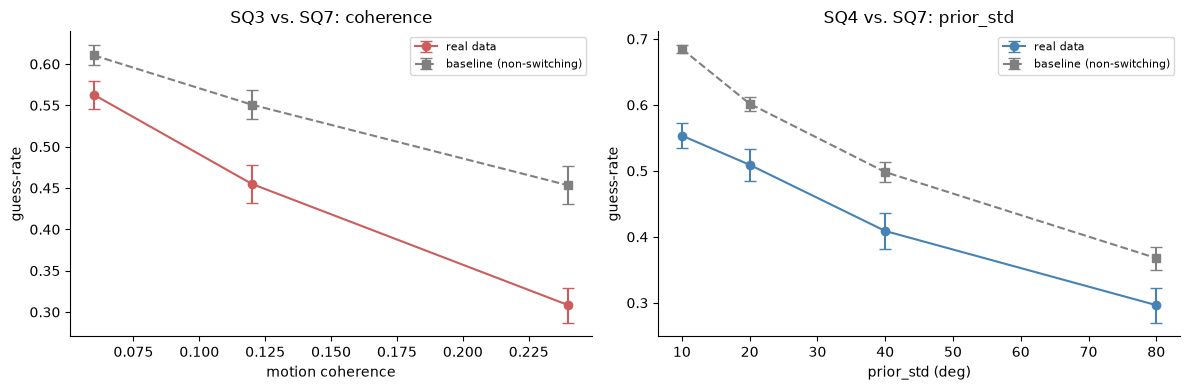

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coh_summary_base = guess_by_condition_baseline.groupby("motion_coherence")["guess_rate_baseline"].agg(["mean", "sem"])
axes[0].errorbar(coh_summary.index, coh_summary["mean"], yerr=coh_summary["sem"], fmt="o-", color="indianred", capsize=4, label="real data")
axes[0].errorbar(coh_summary_base.index, coh_summary_base["mean"], yerr=coh_summary_base["sem"], fmt="s--", color="gray", capsize=4, label="baseline (non-switching)")
axes[0].set_xlabel("motion coherence")
axes[0].set_ylabel("guess-rate")
axes[0].set_title("SQ3 vs. SQ7: coherence")
axes[0].legend(fontsize=8)

ps_summary_base = guess_by_condition_baseline.groupby("prior_std")["guess_rate_baseline"].agg(["mean", "sem"])
axes[1].errorbar(ps_summary.index, ps_summary["mean"], yerr=ps_summary["sem"], fmt="o-", color="steelblue", capsize=4, label="real data")
axes[1].errorbar(ps_summary_base.index, ps_summary_base["mean"], yerr=ps_summary_base["sem"], fmt="s--", color="gray", capsize=4, label="baseline (non-switching)")
axes[1].set_xlabel("prior_std (deg)")
axes[1].set_ylabel("guess-rate")
axes[1].set_title("SQ4 vs. SQ7: prior_std")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. SQ7 verdict (fill in after running)

Compare the printed slopes/p-values and the two plots above:

- **If the baseline (non-switching) slopes are similar in magnitude and significance to the real-data slopes** -> SQ3/SQ4's trend is fully explained by ordinary Bayesian blending; the guess-rate proxy cannot distinguish switching from blending, and this line of analysis is a **dead end** as evidence for a discrete "guessing" mechanism (still a valid, reportable negative result).
- **If the real-data slopes are meaningfully steeper / more significant than baseline** -> there's a real *excess* of "guessing" beyond what blending predicts, which is evidence for something switching-like. In this case, report the **difference** between real and baseline slopes (e.g., via a proper interaction test: `guessed ~ motion_coherence * is_real_data`, pooling both datasets) as the actual finding, not the raw real-data slope alone.
- Either way, this determines whether the "hallucination-like guessing" framing survives contact with the simplest alternative explanation -- exactly the kind of control the NMA guidance flags as essential before trusting any positive result.